In [252]:
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from matplotlib import rc
import xarray as xr
import pandas as pd
from tqdm import tqdm
import warnings
import cartopy.crs as ccrs
from scipy.stats import skew, kurtosis
from numpy import nanmean, nanvar

import sys 
sys.path.append("../scripts")
import InfoTheoryMetrics
from InfoTheoryMetrics import info_RPC

In [ ]:
# Setting the fonts for matplotlib
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)

# uncomment to return fonts to default settings
# plt.rcdefaults()

# Pre-processing

In [249]:
# Load in the datasets
f = xr.open_dataset("../data/ensembles/large_psl_decadal_ensemble_no_extrapolate.nc").drop_dims(["bnds"])
obs = xr.open_dataset("../data/obs/hadslp2/hadslp2_monthly_1850_2004.nc")
obs = obs.where(obs["time.year"]>=1962, drop=True)
obs = obs.where(obs["time.year"]<1972, drop=True)
obs = obs.sortby("lon")

# Interpolate the observations to match the model outputs
with warnings.catch_warnings(action="ignore"):
    obs["time"] = obs.indexes["time"].to_datetimeindex()
obs = obs.interp_like(f, kwargs={"fill_value":"extrapolate"})

# Linearly detrend the data
obs_lin_trend = xr.polyval(obs["time"], obs.psl.polyfit(dim='time', deg=1).polyfit_coefficients)
obs["psl"] = obs["psl"] - obs_lin_trend

f_lin_trend = xr.polyval(f["time"], f.psl.polyfit(dim='time', skipna=True, deg=1).polyfit_coefficients)
f["psl"] = f["psl"] - f_lin_trend

s = f.mean("n")

# Inspecting the Data

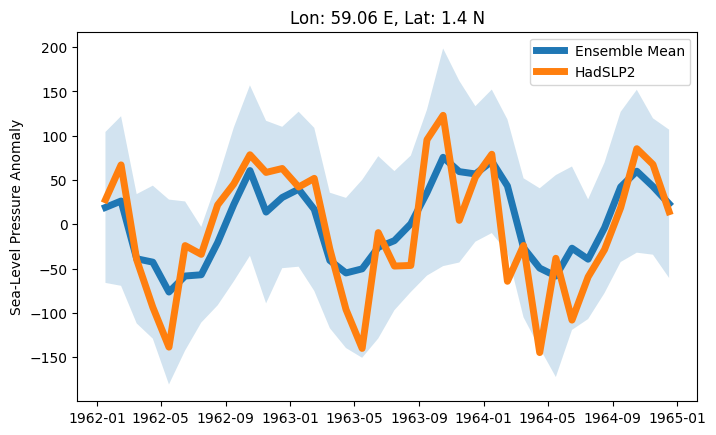

In [336]:
def inspect_data(lat_idx, lon_idx):    
    lat, lon = lat_idx, lon_idx
    T_STOP = 36
    t = f.time.to_numpy().astype("datetime64[m]")
    t = t[:T_STOP]
    f_xy = f.isel(lat=lat, lon=lon).psl.to_numpy()
    f_xy = f_xy[:,:T_STOP]
    s_xy = np.mean(f_xy, axis=0)
    model_spread = np.std(f_xy, axis=0)
    g_xy = obs.isel(lat=lat, lon=lon).psl.to_numpy()
    g_xy = g_xy[:T_STOP]

    fig = plt.figure()
    plt.plot(t, s_xy, linewidth=5, label='Ensemble Mean')
    plt.fill_between(t, s_xy-model_spread, s_xy+model_spread, interpolate=True, alpha=0.2)
    plt.plot(t, g_xy, linewidth=5, label='HadSLP2')
    plt.legend()
    plt.ylabel("Sea-Level Pressure Anomaly")
    fig.set_figwidth(8)

    plt.title(f"Lon: {np.round(f.lon[lon].to_numpy(), 2)} E, Lat: {np.round(f.lat[lat].to_numpy(), 2)} N")
inspect_data(32, 21)

# Make histograms of the climate model outputs and the observation data

In [339]:
# flatten the data in order to make the histograms
flat_s = s.psl.to_numpy().flatten()
flat_obs = obs.psl.to_numpy().flatten()
flat_obs = flat_obs[~np.isnan(flat_obs)]
flat_f = f.psl.to_numpy().flatten()
flat_s = flat_s[~np.isnan(flat_s)]
flat_obs = flat_obs[~np.isnan(flat_obs)]
flat_f = flat_f[~np.isnan(flat_f)]

s_bins, s_edges = np.histogram(flat_s, bins=100, density=True)
obs_bins, obs_edges = np.histogram(flat_obs, bins=100, density=True)
f_bins, f_edges = np.histogram(flat_f, bins=1000, density=True)

s_mean, s_var, s_skew, s_kurt = np.round(nanmean(flat_s), 3), np.round(nanvar(flat_s),3), np.round(skew(flat_s),3), np.round(kurtosis(flat_s),3)
obs_mean, obs_var, obs_skew, obs_kurt = np.round(nanmean(flat_obs), 3), np.round(nanvar(flat_obs),3), np.round(skew(flat_obs),3), np.round(kurtosis(flat_obs),3)
f_mean, f_var, f_skew, f_kurt = np.round(nanmean(flat_f), 3), np.round(nanvar(flat_f),3), np.round(skew(flat_f),3), np.round(kurtosis(flat_f),3)

Sig -- mean=0.044 | var=104535.758 | skew=-0.286 | kurt=2.572
Obs -- mean=-0.0 | var=158673.163 | skew=0.129 | kurt=2.216
Ens -- mean=-0.0 | var=261392.168 | skew=0.016 | kurt=1.66


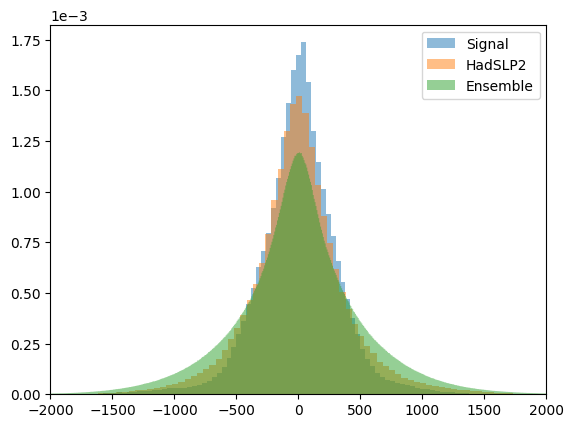

In [340]:
print(f"Sig -- mean={s_mean} | var={s_var} | skew={s_skew} | kurt={s_kurt}")
print(f"Obs -- mean={obs_mean} | var={obs_var} | skew={obs_skew} | kurt={obs_kurt}")
print(f"Ens -- mean={f_mean} | var={f_var} | skew={f_skew} | kurt={f_kurt}")

plt.stairs(s_bins, s_edges, fill=True, alpha=0.5, label='Signal')
plt.stairs(obs_bins, obs_edges, fill=True, alpha=0.5, label='HadSLP2')
plt.stairs(f_bins, f_edges, fill=True, alpha=0.5, label='Ensemble')
plt.legend()
plt.xlim([-2000, 2000])
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0));

# Estimate the RPC from the data

In [254]:
def var_RPC(ensemble:xr.Dataset, signal:xr.Dataset, observation:xr.Dataset):
    rho_o = xr.corr(signal.psl, observation.psl, dim="time")
    rho_o = xr.where(rho_o>0, rho_o, 0)
    var_s = signal.psl.var(dim="time", skipna=True)
    var_total = ensemble.psl.var(dim="time", skipna=True).mean("n")
    rho_m = np.sqrt(var_s / var_total)
    rho = rho_o/rho_m
    return rho_o, rho_m, rho
rho_o, rho_m, rho = var_RPC(f, s, obs)

C:\Users\jaspe\Academics\senior-thesis\Lib\site-packages\xarray\core\nputils.py:224: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)


# Apply information theory to the observations and model outputs

In [152]:
I_fg, I_fs, H_f, H_g = info_RPC(f, s, obs, method='histogram', quant_uncert=True)

Calculating Entropy Metrics: 100%|█████████████████████████████████████████████████████| 64/64 [00:48<00:00,  1.32it/s]


In [266]:
# Calculate the different metrics from the estimated mutual informations
gam_o = I_fg / H_g
gam_m = I_fs / H_f
gam = gam_o / gam_m

lam_o = np.sqrt(1 - np.power(2, -2 * I_fg))
lam_m = np.sqrt(1 - np.power(2, -2 * I_fs))
lam = lam_o/lam_m

## Plot the metrics over the surface

Max gamma=1.137, Max rho=<xarray.DataArray 'psl' ()>
array(2.332)


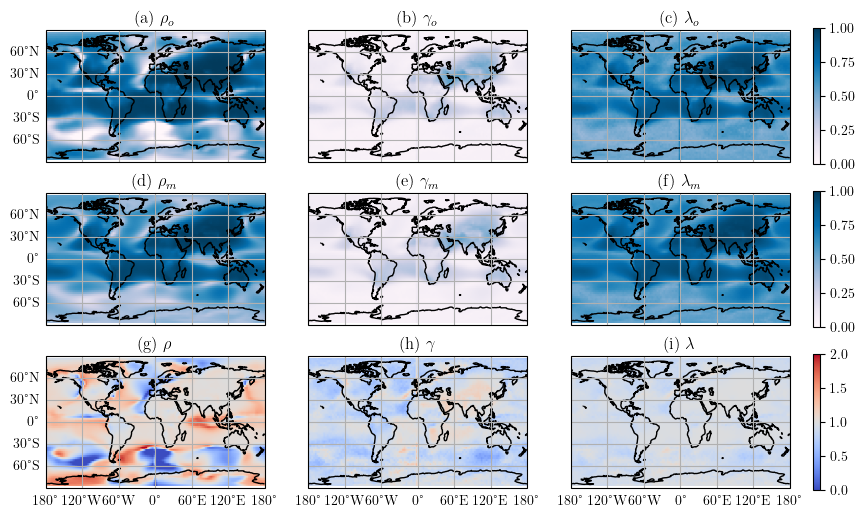

In [268]:
fig, axs = plt.subplots(3,3, subplot_kw=dict(projection=ccrs.PlateCarree()))
_asp = 1.2
cmap = plt.colormaps['PuBu']
cmap2 = plt.colormaps['coolwarm']
PLOT_KWARGS = {"aspect": _asp, 
               "origin":"lower", 
               "extent":(0, 360, -90, 90), 
               "cmap":cmap, 
               "transform":ccrs.PlateCarree()
               }

PLOT_KWARGS2 = {"aspect": _asp, 
               "origin":"lower", 
               "extent":(0, 360, -90, 90), 
               "cmap":cmap2, 
               "transform":ccrs.PlateCarree()
               }

CBAR_KWARGS = {'fraction':0.01, 'pad':0.03}
# Plot the obs predictable component measures
normalizer = Normalize(0, 1)
im = cm.ScalarMappable(norm=normalizer, cmap=cmap)
axs[0,0].imshow(rho_o, norm=normalizer, **PLOT_KWARGS)
axs[0,1].imshow(gam_o[1], norm=normalizer, **PLOT_KWARGS)
axs[0,2].imshow(lam_o[1], norm=normalizer, **PLOT_KWARGS)
fig.colorbar(im, ax=(axs[0,0], axs[0,1], axs[0,2]), **CBAR_KWARGS)

# Plot the model predictable component measures
axs[1,0].imshow(rho_m, norm=normalizer, **PLOT_KWARGS)
axs[1,1].imshow(gam_m[1], norm=normalizer, **PLOT_KWARGS)
axs[1,2].imshow(lam_m[1], norm=normalizer, **PLOT_KWARGS)
fig.colorbar(im, ax=(axs[1,0], axs[1,1], axs[1,2]), **CBAR_KWARGS)

# Plot the RPC measures
norm2 = Normalize(0,2)
im = cm.ScalarMappable(norm=norm2, cmap=cmap2)
axs[2,0].imshow(rho, norm=norm2, **PLOT_KWARGS2)
axs[2,1].imshow(gam[1], norm=norm2, **PLOT_KWARGS2)
axs[2,2].imshow(lam[1], norm=norm2, **PLOT_KWARGS2)
fig.colorbar(im, ax=(axs[2,0], axs[2,1], axs[2,2]), **CBAR_KWARGS)

fig.set_figwidth(10)
fig.set_figheight(6)
print(f"Max gamma={np.round(np.max(lam),3)}, Max rho={np.round(np.max(rho),3)}")

PLOT_TITLES = np.array([
    [r"(a) $\rho_o$", r"(b) $\gamma_o$", r"(c) $\lambda_o$"],
    [r"(d) $\rho_m$", r"(e) $\gamma_m$", r"(f) $\lambda_m$"],
    [r"(g) $\rho$", r"(h) $\gamma$", r"(i) $\lambda$"]
])
m,n = axs.shape
for i in range(m):
    for j in range(n):
        axs[i,j].coastlines()
        gl = axs[i,j].gridlines(draw_labels=True)
        gl.top_labels = False
        gl.right_labels = False 
        if j>=1:
            gl.left_labels=False
        if i<=1:
            gl.bottom_labels=False
        
        axs[i,j].set_title(PLOT_TITLES[i,j])

In [156]:
print("GAM_O AND GAM_M")
print("MAX:", np.max(gam_o.flatten()), np.max(gam_m.flatten()))
print("MAX:", np.mean(gam_o.flatten()), np.mean(gam_m.flatten()))

print("LAM_O AND LAM_M")
print("MAX:", np.max(lam_o.flatten()), np.max(lam_m.flatten()))
print("MAX:", np.mean(lam_o.flatten()), np.mean(lam_m.flatten()))

GAM_O AND GAM_M
MAX: 0.9922160431674707 0.9935209217108472
MAX: 0.7090980982558687 0.7675887635696372


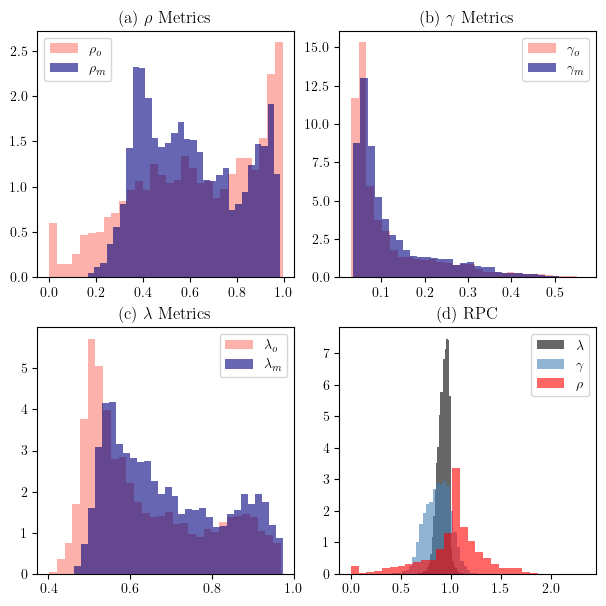

In [269]:
fig, axs = plt.subplots(2,2, figsize=(6,6))
axs[0,0].hist(rho_o.to_numpy().flatten(), alpha=0.6, bins=30, label="$\\rho_o$", color='salmon', density=True)
axs[0,0].hist(rho_m.to_numpy().flatten(), alpha=0.6, bins=30, label="$\\rho_m$", color='navy', density=True)
axs[0,0].legend()
axs[0,0].set_title(r"(a) $\rho$ Metrics")

axs[0,1].hist(gam_o[1].flatten(), alpha=0.6, bins=30, label="$\gamma_o$", color='salmon', density=True)
axs[0,1].hist(gam_m[1].flatten(), alpha=0.6, bins=30, label="$\gamma_m$", color='navy', density=True)
axs[0,1].set_title(r"(b) $\gamma$ Metrics ")
axs[0,1].legend()

axs[1,0].hist(lam_o[1].flatten(), alpha=0.6, bins=30, label="$\lambda_o$", color='salmon', density=True)
axs[1,0].hist(lam_m[1].flatten(), alpha=0.6, bins=30, color='navy', label="$\lambda_m$", density=True)
axs[1,0].set_title(r"(c) $\lambda$ Metrics")
axs[1,0].legend()

axs[1,1].hist(lam[1].flatten(), alpha=0.6, bins=30, label=r"$\lambda$", color='black', density=True)
axs[1,1].hist(gam[1].flatten(), alpha=0.6, bins=30, label=r"$\gamma$", color='steelblue', density=True)
axs[1,1].hist(rho.to_numpy().flatten(), alpha=0.6, bins=30, color='red', label="$\\rho$", density=True)
axs[1,1].set_title("(d) RPC")
axs[1,1].legend()

plt.tight_layout(pad=0.5)

# Quantifying Binning Uncertainty

In [208]:
gam_o_range = np.abs(gam_o[2,:,:] - gam_o[0,:,:])
gam_m_range = np.abs(gam_m[2,:,:] - gam_m[0,:,:])
gam_o_range[:,0] = gam_o_range[:,1]
gam_o_range[:,-1] = gam_o_range[:,-2]
gam_m_range[:,0] = gam_m_range[:,1]
gam_m_range[:,-1] = gam_m_range[:,-2]

lam_o_range = np.abs(lam_o[2,:,:] - lam_o[0,:,:])
lam_m_range = np.abs(lam_m[2,:,:] - lam_m[0,:,:])
lam_o_range[:,0] = lam_o_range[:,1]
lam_o_range[:,-1] = lam_o_range[:,-2]
lam_m_range[:,0] = lam_m_range[:,1]
lam_m_range[:,-1] = lam_m_range[:,-2]

gam_range = np.abs(gam_o[2,:,:]/gam_m[2,:,:] - gam_o[0,:,:]/gam_m[0,:,:])
lam_range = np.abs(lam_o[2,:,:]/lam_m[2,:,:] - lam_o[0,:,:]/lam_m[0,:,:])
gam_range[:,0] = gam_range[:,1]
gam_range[:,-1] = gam_range[:,-2]
lam_range[:,0] = lam_range[:,1]
lam_range[:,-1] = lam_range[:,-2]

In [271]:
print("Mean gam uncertainties:", np.mean(gam_o_range), np.mean(gam_m_range), np.mean(gam_range))
print("Mean lambda uncertainties:", np.mean(lam_o_range), np.mean(lam_m_range), np.mean(lam_range))

Mean gam uncertainties: 0.04458541204522211 0.032688386660848806 0.30342196792556947
Mean lambda uncertainties: 0.19558260227226498 0.11124330111259985 0.14038587876406738


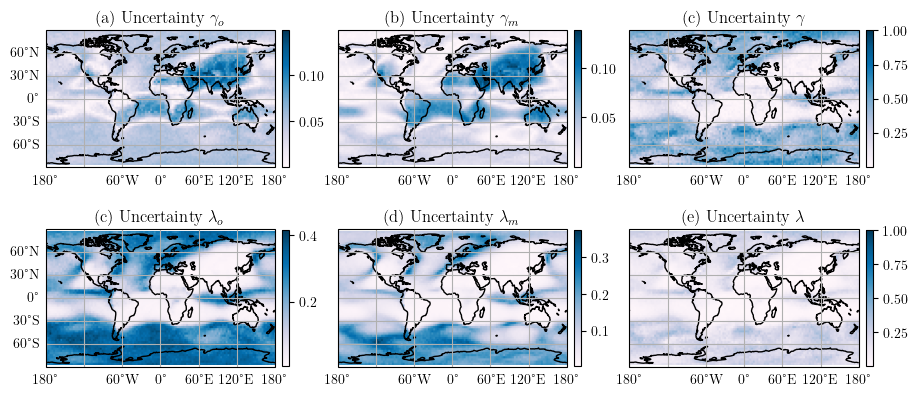

In [270]:
cmap = plt.colormaps['PuBu']
PLOT_KWARGS = {"aspect": 1.2, 
               "origin":"lower", 
               "extent":(0, 360, -90, 90), 
               "cmap":cmap, 
               "transform":ccrs.PlateCarree()
               }

fig, axs = plt.subplots(2,3, subplot_kw=dict(projection=ccrs.PlateCarree()))
settings = {"fraction":0.028, "pad":0.03}
im0 = axs[0,0].imshow(gam_o_range, vmax=np.max(gam_o_range.flatten()), **PLOT_KWARGS)
plt.colorbar(im0, ax=axs[0,0], **settings)
im1 = axs[0,1].imshow(gam_m_range, vmax=np.max(gam_m_range.flatten()), **PLOT_KWARGS)
plt.colorbar(im1, ax=axs[0,1], **settings)
# im2 = axs[2].imshow(gam_range, vmax=np.max(gam_range.flatten()), **PLOT_KWARGS)
im2 = axs[0,2].imshow(gam_range, vmax=1.0, **PLOT_KWARGS)
plt.colorbar(im2, ax=axs[0,2], **settings)

im3 = axs[1,0].imshow(lam_o_range, vmax=np.max(lam_o_range.flatten()), **PLOT_KWARGS)
plt.colorbar(im3, ax=axs[1,0], **settings)
im4 = axs[1,1].imshow(lam_m_range, vmax=np.max(lam_m_range.flatten()), **PLOT_KWARGS)
plt.colorbar(im4, ax=axs[1,1], **settings)
# im2 = axs[2].imshow(gam_range, vmax=np.max(gam_range.flatten()), **PLOT_KWARGS)
im5 = axs[1,2].imshow(lam_range, vmax=1.0, **PLOT_KWARGS)
plt.colorbar(im5, ax=axs[1,2], **settings)

PLOT_TITLES = [
    ["(a) Uncertainty $\gamma_o$", "(b) Uncertainty $\gamma_m$", "(c) Uncertainty $\gamma$"],
    ["(c) Uncertainty $\lambda_o$", "(d) Uncertainty $\lambda_m$", "(e) Uncertainty $\lambda$"],
    
]
for i in range(2):
    for j in range(3):
        axs[i,j].coastlines()
        gl = axs[i,j].gridlines(draw_labels=True)
        gl.top_labels = False
        gl.right_labels = False 
        if j>=1:
            gl.left_labels = False

        axs[i,j].set_title(PLOT_TITLES[i][j])

fig.set_figwidth(9)
fig.set_figheight(4)
plt.tight_layout(pad=0.1)

In [259]:
# How to deal with the nans...?
print("Mean Observation Binning Uncertainty:", np.nanmean(gam_o_range))
print("Mean Model Binning Uncertainty:", np.nanmean(gam_m_range[np.where(gam_m_range<np.inf)]))
print("Mean gamma Binning Uncertainty:", np.nanmean(gam_range[np.where(gam_range<np.inf)]))

Mean Observation Binning Uncertainty: 0.04458541204522211
Mean Model Binning Uncertainty: 0.032688386660848806
Mean gamma Binning Uncertainty: 0.30342196792556947
